In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("../data/raw/train.csv")
train['MSSubClass'] = train['MSSubClass'].astype(str)

# Reapply Phase 5 missing value fixes
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']
for col in none_cols:
    train[col] = train[col].fillna('None')

zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
             'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']
for col in zero_cols:
    train[col] = train[col].fillna(0)

train['LotFrontage'] = train.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
train['Electrical'] = train['Electrical'].fillna(train['Electrical'].mode()[0])
train.loc[train['GarageYrBlt'] > 2010, 'GarageYrBlt'] = 2007

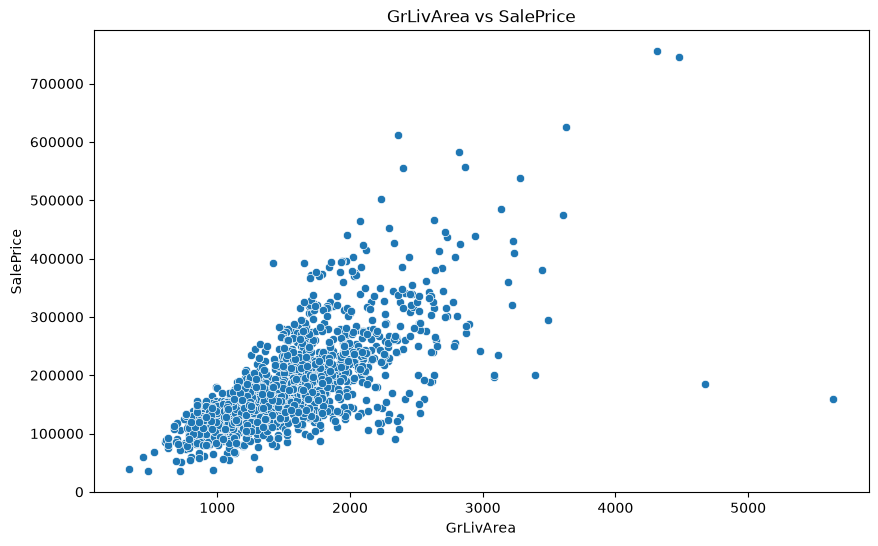

      GrLivArea  SalePrice  OverallQual SaleCondition
523        4676     184750           10       Partial
1298       5642     160000           10       Partial


In [2]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=train['GrLivArea'], y=train['SalePrice'])
plt.title("GrLivArea vs SalePrice")
plt.show()

# Isolate the suspicious points
suspects = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)]
print(suspects[['GrLivArea', 'SalePrice', 'OverallQual', 'SaleCondition']])

In [3]:
train = train[~((train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000))]
print("New shape:", train.shape)

New shape: (1458, 81)


In [4]:
def iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

for col in ['GrLivArea', 'LotArea', 'TotalBsmtSF', 'SalePrice']:
    lower, upper = iqr_bounds(train[col])
    n_outliers = ((train[col] < lower) | (train[col] > upper)).sum()
    print(f"{col}: {n_outliers} IQR outliers (bounds: {lower:.0f} to {upper:.0f})")

GrLivArea: 29 IQR outliers (bounds: 157 to 2747)
LotArea: 66 IQR outliers (bounds: 1461 to 17683)
TotalBsmtSF: 59 IQR outliers (bounds: 43 to 2049)
SalePrice: 61 IQR outliers (bounds: 3812 to 340112)


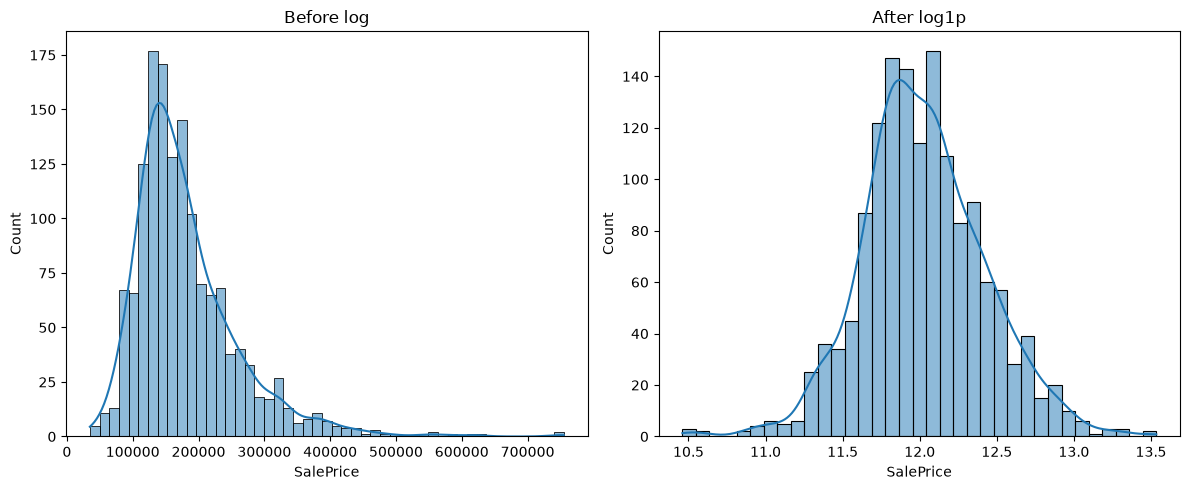

In [5]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(train['SalePrice'], kde=True)
plt.title("Before log")

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(train['SalePrice']), kde=True)
plt.title("After log1p")
plt.tight_layout()
plt.show()

In [6]:
train.to_csv("../data/processed/train_cleaned.csv", index=False)